## Analysis of impact of podcast features on digital asset price prediction

To run this notebook you will need a historic metrics download from audioalpha.io.

## Setup
Necessary imports

In [2]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from datetime import datetime
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
import sklearn
from sklearn.ensemble import RandomForestRegressor
import time  # for rate limiting if needed
from sklearn.pipeline import Pipeline
from scipy.stats import pearsonr
import requests
import time
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
from scipy.stats import ttest_rel

plt.close('all')

## Helper functions

Downloading prices:

In [3]:
# Function to fetch historical BTC/USD prices from Binance API
def fetch_btc_prices(ticker, start_date, end_date):
    """
    Fetch historical daily BTC/USDT closing prices from Binance public API.
    Handles pagination for ranges >1000 days.

    Args:
        start_date (pd.Timestamp): start date
        end_date   (pd.Timestamp): end date

    Returns:
        pd.DataFrame: index=snapshot_date (datetime), column='price' (close)
    """
    symbol = ticker + 'USDT'
    interval = '1d'
    limit = 1000  # max per request

    # Convert dates to milliseconds timestamps
    start_ts = int(start_date.timestamp() * 1000)
    end_ts = int(end_date.timestamp() * 1000) + 86399999  # end of day in ms

    base_url = "https://api.binance.com/api/v3/klines"

    all_klines = []
    current_start = start_ts

    while current_start < end_ts:
        params = {
            'symbol': symbol,
            'interval': interval,
            'startTime': current_start,
            'limit': limit
        }
        if current_start + (limit * 86400000) < end_ts:  # rough ms per day
            params['endTime'] = current_start + (limit * 86400000)
        else:
            params['endTime'] = end_ts

        response = requests.get(base_url, params=params)
        if response.status_code != 200:
            raise ValueError(f"Binance API error: {response.status_code} - {response.text}")

        data = response.json()
        if not data:
            break

        all_klines.extend(data)
        current_start = data[-1][6] + 1  # closeTime is index 6
        time.sleep(0.1)  # polite rate limiting

    if not all_klines:
        raise ValueError("No data returned from Binance API")

    # Create DataFrame
    df = pd.DataFrame(all_klines, columns=[
        'open_time', 'open', 'high', 'low', 'close', 'volume',
        'close_time', 'quote_volume', 'trades', 'taker_buy_base', 'taker_buy_quote', 'ignore'
    ])

    # Convert open_time to snapshot_date
    df['snapshot_date'] = pd.to_datetime(df['open_time'], unit='ms').dt.normalize()
    df['price'] = df['close'].astype(float)

    # Keep only date and price, drop duplicates
    df = df[['snapshot_date', 'price']].drop_duplicates(subset='snapshot_date')
    df = df.set_index('snapshot_date')

    # Filter to requested range
    df = df.loc[start_date:end_date]

    return df

Load the datafile:

In [4]:
def load_datafile(file, start_date, end_date, ticker):
    # file = '../data/correlation_query-2026-03-03_52126_', ticker, '.csv'
    # file = '../data/correlation_query-2026-03-03_52126_DOGE.csv'
    df = pd.read_csv(file)


    # Columns to drop
    drop_cols = [
        'wordcloud', 'created_at', 'updated_at', 'daily_narrative_summary',
        'headline', 'market_sentiment_shape', 'snapshot_id.1',
         'regime_justification', 'key_tensions', 'delta_narrative',
        'market_psychology_summary'
    ] #'sentiment_strength_index'

    drop_cols = [col for col in drop_cols if col in df.columns]
    df = df.drop(columns=drop_cols)

    # Columns to exclude from alpha_ prefix
    exclude_prefix = ['days_since_last_mention', 'snapshot_id', 'ticker', 'episode_count', 'snapshot_date']

    # Prepend 'alpha_' to all other columns
    df.columns = [col if col in exclude_prefix else 'alpha_' + col for col in df.columns]

    # print(df.columns)
    df['snapshot_date'] = pd.to_datetime(df['snapshot_date'], errors='coerce')

    # Drop rows where snapshot_date could not be parsed
    df = df.dropna(subset=['snapshot_date'])

    # Filter the dataframe
    df = df.loc[(df['snapshot_date'] >= start_date) & (df['snapshot_date'] <= end_date)]
    # print("Length after filtering:", len(df))

    # Filter for BTC ticker
    df_btc = df[df['ticker'] == ticker].copy()
    # Parse snapshot_date to datetime
    df_btc['snapshot_date'] = pd.to_datetime(df_btc['snapshot_date'])

    # Get min and max dates for price fetching
    # start_date = df_btc['snapshot_date'].min().strftime('%Y-%m-%d')
    # df_btc['snapshot_date'].max().strftime('%Y-%m-%d'))

    return df_btc


Adding the target column

In [5]:
def add_target(df, target_type):

    df['return'] = df['price'].pct_change(fill_method=None)

    match target_type:
        case 'next_day_return':
            df['target'] = df['return'].shift(-1)
        case 'log_return_1d':
            df['log_return'] = np.log(df['price']).diff()
            df['target'] = df['log_return'].shift(-1)
        case 'return_7d':
            df['return_7d'] = df['price'].pct_change(periods=7, fill_method=None)
            df['target'] = df['return_7d'].shift(-7)
        case 'log_return_7d':
            df['target'] = ( np.log(df['price'].shift(-7))  - np.log(df['price']))
        case 'log_return_3d':
            df['target'] = ( np.log(df['price'].shift(-3))  - np.log(df['price']))

    # for future when doing classification:
    # df_btc['next_day_up'] = (df_btc['next_day_return'] > 0).astype(int)
    # df_btc['next_7d_up'] = (df_btc['next_7d_return'] > 0).astype(int)
    return df['target']

Let's do correlation analysis:

In [6]:
def correlation_analysis(df, cor_method = 'pearson', target_cols = ['target'], visualise = False, top_n = 1000):

    exclude_cols = ["price", "return", "target", "log_return", 'log_return_1d', 'log_return_3d','log_return_7d'] + target_cols

    features = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude_cols ]

    corr_df = df[features + target_cols]
    corr_table = corr_df[features + target_cols].corr(method=cor_method)
    corr_table = corr_table.loc[features, target_cols]
    corr_table["max_abs_corr"] = corr_table.abs().max(axis=1)
    correlations = corr_table.sort_values(by="max_abs_corr", ascending=False).drop(columns="max_abs_corr")

    print("Correlations:")
    print(correlations.to_markdown())

    if visualise:

        # Take top N features (e.g., 15)
        top_n = 15
        correlations = corr_table.sort_values('max_abs_corr', ascending=False).head(top_n).drop(columns='max_abs_corr')

        # Absolute values for color intensity
        abs_corr = correlations.abs()

        # Plot
        plt.figure(figsize=(10, max(6, len(correlations) * 0.4)))
        heatmap = sns.heatmap(
            abs_corr,
            annot=False,                    # we'll overlay text manually
            cmap='coolwarm',
            vmin=0,
            vmax=abs_corr.max().max() + 0.05,
            linewidths=0.5,
            cbar_kws={'label': 'Absolute Correlation (predictive strength)'}
        )

        # Overlay signed correlation as text
        for i in range(abs_corr.shape[0]):
            for j in range(abs_corr.shape[1]):
                val = correlations.iloc[i, j]
                color = 'white' if abs(val) > 0.5 else 'black'  # readable contrast
                text = f"{val:.2f}"
                if val > 0:
                    text = f"+{text}"  # optional + sign
                heatmap.text(j + 0.5, i + 0.5, text,
                             color=color, ha='center', va='center', fontsize=10, fontweight='bold')

        plt.title('AudioAlpha Features Predictive Power\n'
                  '(Color = |Correlation| • Text = signed value • Sorted by max |correlation| across targets)')
        plt.xlabel('Target')
        plt.ylabel('Feature')
        plt.tight_layout()
        plt.show()


In [7]:
def correlation_analysis_stats(df, cor_method='pearson', target_cols=['target'], visualise=False, top_n=1000):

    exclude_cols = ["price","return","target","log_return",
                    "log_return_1d","log_return_3d","log_return_7d"] + target_cols

    features = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude_cols]

    corr_vals = []
    p_vals = []

    for feat in features:

        corr_row = {}
        p_row = {}

        for tgt in target_cols:

            x = df[feat]
            y = df[tgt]

            valid = x.notna() & y.notna()
            x = x[valid]
            y = y[valid]

            if len(x) < 2:
                corr = np.nan
                pval = np.nan
            else:
                if cor_method == "pearson":
                    corr, pval = stats.pearsonr(x, y)
                elif cor_method == "spearman":
                    corr, pval = stats.spearmanr(x, y)

            corr_row[tgt] = corr
            p_row[tgt] = pval

        corr_vals.append(corr_row)
        p_vals.append(p_row)

    corr_numeric = pd.DataFrame(corr_vals, index=features)
    p_table = pd.DataFrame(p_vals, index=features)

    corr_numeric["max_abs_corr"] = corr_numeric.abs().max(axis=1)
    corr_numeric = corr_numeric.sort_values("max_abs_corr", ascending=False)

    # Create printable table with stars
    corr_display = corr_numeric[target_cols].copy().astype(object)

    pvals = p_table[target_cols].values.flatten()

    mask = ~np.isnan(pvals)
    adj = np.full_like(pvals, np.nan)

    adj[mask] = multipletests(pvals[mask], method="fdr_bh")[1]

    p_table_fdr = pd.DataFrame(
        adj.reshape(p_table[target_cols].shape),
        index=p_table.index,
        columns=p_table.columns
)

    for col in target_cols:
        for i in corr_display.index:

            corr = corr_numeric.loc[i, col]
            p = p_table_fdr.loc[i, col]

            if pd.isna(p):
                stars = ""
            elif p < 0.001:
                stars = "***"
            elif p < 0.01:
                stars = "**"
            elif p < 0.05:
                stars = "*"
            else:
                stars = ""

            corr_display.loc[i, col] = f"{corr:.3f}{stars}" if not pd.isna(corr) else ""

    print("Correlations (* p<0.05, ** p<0.01, *** p<0.001):")
    print(corr_display.to_markdown())

    # ---- Heatmap ----
    if visualise:

        top_corr = corr_numeric.head(top_n)[target_cols]
        abs_corr = top_corr.abs()

        plt.figure(figsize=(10, max(6, len(top_corr)*0.4)))

        heatmap = sns.heatmap(
            abs_corr,
            annot=False,
            cmap='Oranges',
            vmin=0,
            vmax=abs_corr.max().max()+0.05,
            linewidths=0.5,
            cbar_kws={'label': 'Absolute Correlation'}
        )

        for i in range(abs_corr.shape[0]):
            for j in range(abs_corr.shape[1]):

                val = top_corr.iloc[i, j]
                p = p_table_fdr.loc[top_corr.index[i], top_corr.columns[j]]

                if pd.isna(val):
                    continue

                color = 'white' if abs(val) > 0.5 else 'black'

                text = f"{val:.2f}"
                if val > 0:
                    text = f"+{text}"

                # mark significance
                if not pd.isna(p) and p < 0.001:
                    text += "*"

                heatmap.text(
                    j + 0.5,
                    i + 0.5,
                    text,
                    color=color,
                    ha='center',
                    va='center',
                    fontsize=10,
                    fontweight='bold'
                )

        plt.title("Feature Predictive Power")
        plt.xlabel("Target")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.savefig('../../data/correlations.png', dpi=300)
        plt.show()

Quick function to easily load various datasets:

In [8]:
def load_df(file, start_date, end_date, ticker):
    # load audioalpha features and merge with price data
    df = load_datafile(file, start_date, end_date, ticker)
    df_prices = fetch_btc_prices(ticker, start_date, end_date)
    df = df.merge(df_prices, on='snapshot_date', how='left')
    df.replace('', np.nan, inplace=True)
    return df

In [9]:
def get_splits_process(df, split_pct=0.8, include_return_price = False, price_return_only=False):
    # Ensure chronological order
    df = df.sort_values("snapshot_date").reset_index(drop=True)

    if not include_return_price:
        numeric_features = [col for col in df.columns if df[col].dtype in ['int64','float64'] and col not in ['log_return', 'return', 'price', 'target']] # 'return',xxx
    else:
        numeric_features = [col for col in df.columns if df[col].dtype in ['int64','float64'] and col not in ['target']]


    categorical_features = ['alpha_regime']
    features = numeric_features + categorical_features

    if price_return_only:
        numeric_features = ['return'] #'price', '
        categorical_features = []
        features = numeric_features + categorical_features

    df[categorical_features] = df[categorical_features].astype(str)
    X = df[features].fillna(0)  # Simple imputation; adjust as needed
    y = df['target'].fillna(0)  # Drop NaNs or impute

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_features),      # scale numeric features
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)  # one-hot encode regime
        ]
    )

    # Split data out-of-time
    split_idx = int(len(X) * split_pct)
    X_train = X.iloc[:split_idx]
    X_test  = X.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_test  = y.iloc[split_idx:]

    return X_train, X_test, y_train, y_test, preprocessor



random forest function:


In [10]:
def run_randomForest(X_train, X_test, y_train, y_test, preprocessor, n_estimators=500, min_samples_leaf=5, min_samples_split=10, max_features="sqrt", bootstrap=True, max_samples=0.8, max_depth = 5, print_importances=False):


    model = RandomForestRegressor(n_estimators=n_estimators, min_samples_leaf=min_samples_leaf, min_samples_split=min_samples_split, max_features=max_features, bootstrap=bootstrap, max_samples=max_samples, max_depth = max_depth, random_state=42)

    pipe = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)

    # Feature importances
    feature_names = pipe.named_steps['preprocess'].get_feature_names_out()
    rf = pipe.named_steps['model']



    # importances = pd.DataFrame({'Feature': features, 'Importance': pipe.feature_importances_}).sort_values(by='Importance', ascending=False)
    # Print feature importances table
    if print_importances:
        importances = pd.DataFrame({
        'Feature': feature_names,
        'Importance': rf.feature_importances_
    }).sort_values(by='Importance', ascending=False)
        print("\nFeature Importances:")
        print(importances.to_markdown(index=False))


    # Print only correlation between next_day_return and alpha_market_sentiment_mean
    # print("Correlation (alpha_market_sentiment_mean vs next_day_return):")
    # print(correlations.loc['alpha_market_sentiment_mean', 'next_day_return'])

    y_pred = pipe.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    print(f"\nModel RandomForest R² on test set: {r2:.4f}")
    corr, pval = pearsonr(y_test, y_pred)
    print("Correlation:", corr, "p-value:", pval)
    # print("R² on real data:", score)
    # print("Permutation p-value:", pvalue)

    return r2, corr, pval



SVM:


In [11]:
def run_svm(X_train, X_test, y_train, y_test, preprocessor, C = 0.1, epsilon=0.001, kernel="rbf", gamma=0.01, grid_search = False, tol=1e-4, shrinking=True, max_iter=10000, degree=3):


    pipe = Pipeline([
            # ("scaler", StandardScaler()),
            ('preprocess', preprocessor),
            ("modelB", sklearn.svm.SVR(kernel=kernel, C=C, epsilon=epsilon, gamma=gamma, shrinking=shrinking, tol=tol, max_iter=max_iter,degree=degree )),
        ])

    if grid_search:
        param_grid = {
            "modelB__C": [0.1, 1, 10, 100],
            "modelB__gamma": [1e-3, 1e-2, 1e-1, "scale"],
            "modelB__epsilon": [0.001, 0.005, 0.01, 0.02]
        }

        # TODO might not work with catogorical features
        tscv = TimeSeriesSplit(n_splits=5)
        grid = GridSearchCV(
            pipe,
            param_grid,
            cv=tscv,
            scoring="r2",  # or "neg_mean_squared_error"
            n_jobs=-1
        )
        grid.fit(X_train, y_train)
        y_predB = grid.predict(X_test)
        print("Best params:", grid.best_params_)
        print("Best CV score:", grid.best_score_)
        best_model = grid.best_estimator_
        y_predB = best_model.predict(X_test)
        r2B = r2_score(y_test, y_predB)
        print(f"\nModel R² on SVM test set: {r2B:.4f}")
        corr, pval = pearsonr(y_test, y_predB)
        print("Correlation:", corr, "p-value:", pval)
        return r2B, corr, pval

    else:

        pipe.fit(X_train, y_train)
        y_predB = pipe.predict(X_test)
        r2B = r2_score(y_test, y_predB)
        print(f"\nModel R² on SVM test set: {r2B:.4f}")
        corr, pval = pearsonr(y_test, y_predB)
        print("Correlation:", corr, "p-value:", pval)
        return r2B, corr, pval

AdaBoost:

In [12]:
def run_adaBoost(X_train, X_test, y_train, y_test, preprocessor, n_estimators=100, learning_rate=0.05,max_depth=3 , min_samples_leaf=5, loss='square'):

    base = DecisionTreeRegressor(
    max_depth=max_depth,
    min_samples_leaf=min_samples_leaf
    )

    pipe = Pipeline([
        # ("scaler", StandardScaler()),
        ('preprocess', preprocessor),
        ("modelC", sklearn.ensemble.AdaBoostRegressor(estimator=base, n_estimators=n_estimators, learning_rate=learning_rate, loss=loss, random_state=42)),
    ])
    # modelC = sklearn.ensemble.AdaBoostRegressor(n_estimators=100)
    # modelC.fit(X_train, y_train)
    # y_predC = modelC.predict(X_test)
    pipe.fit(X_train, y_train)
    y_predC = pipe.predict(X_test)
    r2C = r2_score(y_test, y_predC)
    print(f"\nModel R² on ADAboost test set: {r2C:.4f}")
    corr, pval = pearsonr(y_test, y_predC)
    print("Correlation:", corr, "p-value:", pval)

    return r2C, corr, pval

In [13]:
def plot_improvement(results_all_df, results_price_df):


    improvement = results_all_df.copy()
    improvement['R2'] = results_all_df['R2'].values - results_price_df['R2'].values
    improvement['Corr'] = results_all_df['Corr'].values - results_price_df['Corr'].values
    combined = pd.concat([
        results_price_df.assign(Features="Price only"),
        results_all_df.assign(Features="All features")
    ])

    improvement_df = results_all_df.copy()
    improvement_df['R2_gain'] = results_all_df['R2'] - results_price_df['R2']
    r2_matrix = improvement_df.pivot(index='Target', columns='Model', values='R2')

    plt.figure(figsize=(8,5))
    sns.heatmap(
        r2_matrix,
        annot=True,
        fmt=".3f",
        cmap="RdYlGn",
        center=0
    )
    plt.title("Performance Gain Using All Features (ΔR²)")
    plt.tight_layout()
    plt.show()



    sns.set(style="white")  # cleaner background

    plt.figure(figsize=(8,5))
    ax = sns.barplot(
        data=combined,
        x="Target",
        y="R2",
        hue="Features",
        palette="tab20c",
        edgecolor="white",
        errorbar=None
    )

    # Add R² values on top of bars
    for p in ax.patches:
        height = p.get_height()
        if height == 0:
            continue  # skip bars with 0 height
        ax.annotate(f"{height:.3f}",
                    (p.get_x() + p.get_width()/2., height),
                    ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 2),
                    textcoords='offset points')

    ax.set_title("Model Performance: Price vs All Features", fontsize=14)
    ax.set_ylabel("R²", fontsize=12)
    ax.set_xlabel("Target", fontsize=12)
    ax.legend(title="Features")
    plt.tight_layout()
    plt.show()





    plt.figure(figsize=(8,5))
    ax = sns.barplot(
        data=improvement_df,
        x="Target",
        y="R2_gain",
        hue="Model",
        palette="tab20c",
        edgecolor="white",
        errorbar=None
    )

    # Add ΔR² values on top of bars
    for p in ax.patches:
        height = p.get_height()
        if height == 0:
            continue  # skip bars with 0 height
        ax.annotate(f"{height:.3f}",
                    (p.get_x() + p.get_width()/2., height),
                    ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 2),
                    textcoords='offset points')

    # Horizontal line at 0
    # ax.axhline(0, color="black", linewidth=1)

    ax.set_title("R² Gain from Using All Features", fontsize=14)
    ax.set_ylabel("ΔR²", fontsize=12)
    ax.set_xlabel("Target", fontsize=12)
    ax.legend(title="Model")
    plt.tight_layout()
    plt.show()
    t, p = ttest_rel(results_all_df['R2'], results_price_df['R2'])

    print("Paired t-test p-value:", p)

## Analysis



Let's start by loading and preprocessing the data:

In [13]:
file = '../../data/audioalpha_5march.csv'
start_date = pd.to_datetime('2024-01-1')
start_date_lt = pd.to_datetime('2024-01-1')
end_date = pd.to_datetime('2026-3-4')
ticker = 'BTC'

df_btc = load_df(file, start_date, end_date, ticker)
df_btc_lt = load_df(file, start_date_lt, end_date, ticker)

### Correlation analysis
Let's do a correlation analysis with a few possble targets to identify the most impactful features:

6749
Correlations (* p<0.05, ** p<0.01, *** p<0.001):
|                                    | log_return_1d   | log_return_3d   | log_return_7d   |
|:-----------------------------------|:----------------|:----------------|:----------------|
| alpha_market_sentiment_median      | -0.184***       | -0.178***       | -0.186***       |
| alpha_sentiment_strength_index     | -0.167***       | -0.175***       | -0.177***       |
| alpha_market_sentiment_mean        | -0.167***       | -0.177***       | -0.177***       |
| alpha_sentiment_strength_index_raw | -0.155***       | -0.165***       | -0.161***       |
| alpha_sentiment_high               | -0.131***       | -0.121***       | -0.125***       |
| alpha_sentiment_mean               | -0.117***       | -0.113***       | -0.119***       |
| alpha_sentiment_median             | -0.108***       | -0.105***       | -0.115***       |
| alpha_episode_volume_score         | -0.115***       | -0.108***       | -0.102***       |
| alpha_sentimen

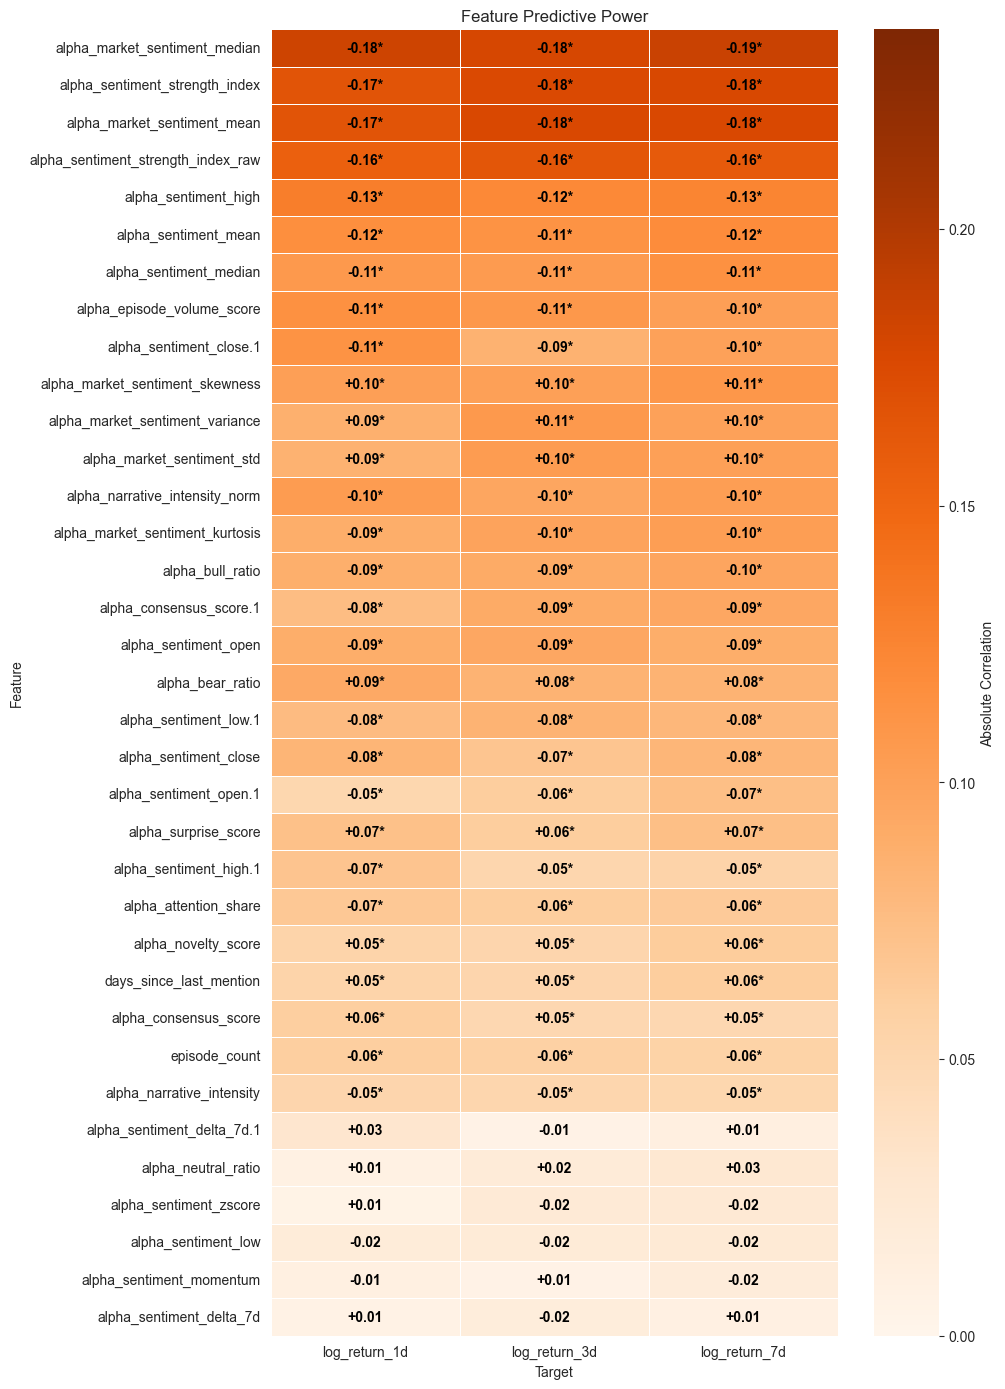

In [14]:
file = '../../data/audioalpha_5march.csv'
start_date = pd.to_datetime('2024-01-1')
end_date = pd.to_datetime('2026-3-4')

tickers = ['BTC','ETH','DOGE','SOL','BNB','XRP','ADA','AVAX','LINK','MATIC']
target_cols = ['log_return_1d', 'log_return_3d', 'log_return_7d']

dfs = []

for ticker in tickers:
    df = load_df(file, start_date_lt, end_date, ticker)
    for target in target_cols:
        df[target] = add_target(df, target_type=target)
    dfs.append(df)

df_cor = pd.concat(dfs, ignore_index=True)
print(len(df_cor))
correlation_analysis_stats(df_cor, cor_method = 'pearson', target_cols = target_cols, visualise=True, top_n = 35)
# with p-values and Benjamini-Hockberg correction.

### Regression exploration
Let's build some regression models to see how much predictive power the features have:

Data preparation for regression models:

In [14]:
file = '../../data/audioalpha_5march.csv'
start_date = pd.to_datetime('2024-01-1')
start_date_lt = pd.to_datetime('2024-01-1')
end_date = pd.to_datetime('2026-03-4')
ticker = 'BTC'

df_btc = load_df(file, start_date, end_date, ticker)
# df_btc_lt = load_df(file, start_date_lt, end_date, ticker)

df_btc['target'] = add_target(df_btc, target_type='log_return_1d')
X_train, X_test, y_train, y_test, preprocessor = get_splits_process(df_btc, split_pct=0.8, include_return_price = False)
# print(X_train.columns)

In [15]:
r2, corr, pval = run_randomForest(X_train, X_test, y_train, y_test, preprocessor = preprocessor, n_estimators=1000, min_samples_leaf=5, min_samples_split=10, max_features="sqrt", bootstrap=True, max_samples=0.6, max_depth = 5, print_importances=False)
r2, corr, pval = run_svm(X_train, X_test, y_train, y_test, preprocessor = preprocessor, C = 0.1, epsilon=0.005, kernel="rbf", gamma=0.001, grid_search = False, tol=1e-4, shrinking=True, max_iter=10000, degree=3)
r2, corr, pval = run_adaBoost(X_train, X_test, y_train, y_test, preprocessor = preprocessor, n_estimators=20, learning_rate=0.05,max_depth=3 , min_samples_leaf=20, loss='exponential')


Model RandomForest R² on test set: -0.0016
Correlation: 0.28371825928885086 p-value: 0.0002899869383116957

Model R² on SVM test set: 0.0250
Correlation: 0.3504253297372144 p-value: 5.947201129841935e-06

Model R² on ADAboost test set: -0.0308
Correlation: 0.24302901449834896 p-value: 0.002023828168761047


## Run regression experiment

In [16]:
def show_results(results_df, show_p=True):

    # Pivot matrices
    r2_matrix = results_df.pivot(index='Target', columns='Model', values='R2')
    corr_matrix = results_df.pivot(index='Target', columns='Model', values='Corr')
    p_matrix = results_df.pivot(index='Target', columns='Model', values='p-value')

    # Build annotation matrix
    annot = r2_matrix.copy().astype(str)

    for i in r2_matrix.index:
        for j in r2_matrix.columns:
            val = r2_matrix.loc[i, j]
            p = p_matrix.loc[i, j]

            if show_p and p < 0.05 and val > 0.:
                annot.loc[i, j] = f"{val:.3f}*"
            else:
                annot.loc[i, j] = f"{val:.3f}"

    plt.figure(figsize=(8, 5))
    sns.heatmap(
        r2_matrix,
        annot=annot,
        fmt="",
        cmap="Oranges",
        vmin=-0.0,
        vmax=0.4
    )

    plt.title("Model Performance (R²) across Targets (* p < 0.05)")
    plt.tight_layout()
    plt.savefig("model_r2_matrix.png")
    plt.show()

    return r2_matrix, corr_matrix

def run_all_model(X_train, X_test, y_train, y_test, preprocessor, results):
     # Run models
    r2_rf, corr_rf, pval_rf = run_randomForest(X_train, X_test, y_train, y_test,
                                               preprocessor=preprocessor, n_estimators=1000, min_samples_leaf=5, min_samples_split=10, max_features="sqrt", bootstrap=True, max_samples=0.6, max_depth = 5, print_importances=False)
    r2_svm, corr_svm, pval_svm = run_svm(X_train, X_test, y_train, y_test,preprocessor=preprocessor, C = 0.1, epsilon=0.005, kernel="rbf", gamma=0.001, grid_search = False, tol=1e-4, shrinking=True, max_iter=10000, degree=3)
    r2_ada, corr_ada, pval_ada = run_adaBoost(X_train, X_test, y_train, y_test, preprocessor=preprocessor, n_estimators=20, learning_rate=0.05,max_depth=3 , min_samples_leaf=20, loss='exponential')

    results.append([target, 'RandomForest', r2_rf, corr_rf, pval_rf])
    results.append([target, 'SVM', r2_svm, corr_svm, pval_svm])
    results.append([target, 'AdaBoost', r2_ada, corr_ada, pval_ada])

    return results




In [17]:
plt.close('all')

In [21]:
file = '../../data/audioalpha_5march.csv'
start_date = pd.to_datetime('2024-01-1')
end_date = pd.to_datetime('2026-03-4')
ticker = 'BTC'

data = load_df(file, start_date, end_date, ticker)

# Example for one target
targets = ['log_return_1d', 'log_return_3d', 'log_return_7d']
models = ['RandomForest', 'SVM', 'AdaBoost']



Feature Importances:
| Feature                                           |   Importance |
|:--------------------------------------------------|-------------:|
| num__alpha_sentiment_zscore                       |  0.0540327   |
| num__alpha_episode_volume_score                   |  0.0517481   |
| num__alpha_sentiment_mean                         |  0.044108    |
| num__alpha_market_sentiment_skewness              |  0.0415884   |
| num__alpha_surprise_score                         |  0.0402022   |
| num__alpha_bull_ratio                             |  0.037931    |
| num__alpha_sentiment_strength_index               |  0.0367609   |
| num__alpha_sentiment_strength_index_raw           |  0.0351062   |
| num__alpha_market_sentiment_mean                  |  0.034072    |
| num__alpha_neutral_ratio                          |  0.033633    |
| num__alpha_sentiment_delta_7d.1                   |  0.033593    |
| num__alpha_narrative_intensity                    |  0.0302303   |
| num__alpha

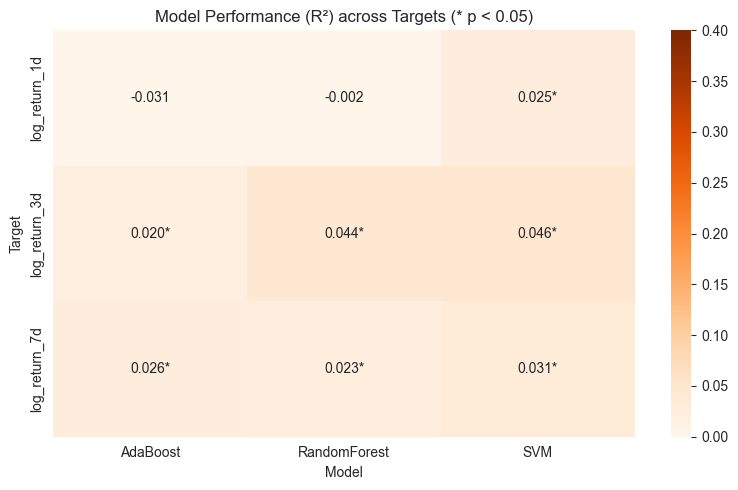

(Model          AdaBoost  RandomForest       SVM
 Target                                         
 log_return_1d -0.030823     -0.001617  0.025013
 log_return_3d  0.020297      0.043691  0.046247
 log_return_7d  0.026363      0.022783  0.031257,
 Model          AdaBoost  RandomForest       SVM
 Target                                         
 log_return_1d  0.243029      0.283718  0.350425
 log_return_3d  0.371449      0.392627  0.390168
 log_return_7d  0.308107      0.258832  0.307343)

In [22]:
# AA data
df_btc = data
results = []
for target in targets:
    df_btc['target'] = add_target(df_btc, target_type=target)
    X_train, X_test, y_train, y_test, preprocessor = get_splits_process(
        df_btc, split_pct=0.8, include_return_price=False
    )
    results = run_all_model(X_train, X_test, y_train, y_test, preprocessor, results)
# results_price = run_all_model(X_train, X_test, y_train, y_test, preprocessor)

results_audioalpha_df = pd.DataFrame(results, columns=['Target', 'Model', 'R2', 'Corr', 'p-value'])
show_results(results_audioalpha_df)


Model RandomForest R² on test set: 0.1903
Correlation: 0.4479521427215177 p-value: 3.207502622135418e-09

Model R² on SVM test set: 0.1338
Correlation: 0.42430606848464714 p-value: 2.493796673059908e-08

Model R² on ADAboost test set: 0.0344
Correlation: 0.3413180807346132 p-value: 1.0683717688922276e-05

Model RandomForest R² on test set: 0.2396
Correlation: 0.5232385440386351 p-value: 1.484399970701031e-12

Model R² on SVM test set: 0.1636
Correlation: 0.48500387458251026 p-value: 9.253547822045393e-11

Model R² on ADAboost test set: 0.1529
Correlation: 0.4523663377335948 p-value: 2.1489288690915734e-09

Model RandomForest R² on test set: 0.2230
Correlation: 0.49992055152600134 p-value: 1.9609680875963156e-11

Model R² on SVM test set: 0.1483
Correlation: 0.4679518538345879 p-value: 4.987338422391626e-10

Model R² on ADAboost test set: 0.2569
Correlation: 0.5103813503001297 p-value: 6.311214167707067e-12


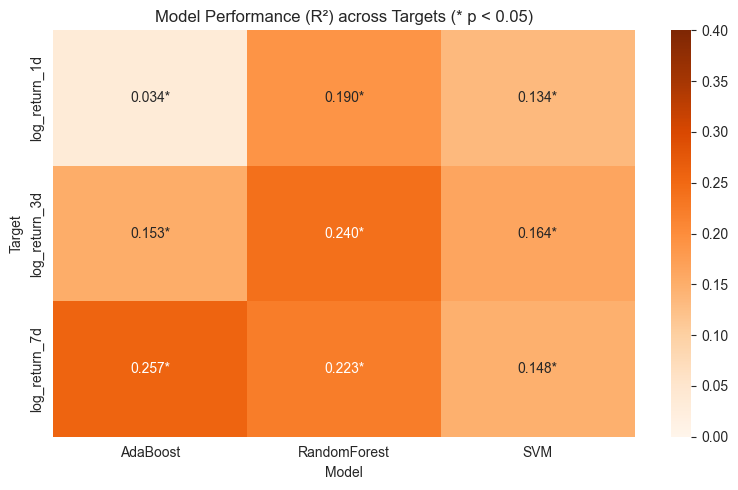

(Model          AdaBoost  RandomForest       SVM
 Target                                         
 log_return_1d  0.034380      0.190311  0.133822
 log_return_3d  0.152939      0.239628  0.163649
 log_return_7d  0.256850      0.222973  0.148338,
 Model          AdaBoost  RandomForest       SVM
 Target                                         
 log_return_1d  0.341318      0.447952  0.424306
 log_return_3d  0.452366      0.523239  0.485004
 log_return_7d  0.510381      0.499921  0.467952)

In [24]:
# AA data
df_btc = data
results = []
for target in targets:
    df_btc['target'] = add_target(df_btc, target_type=target)
    X_train, X_test, y_train, y_test, preprocessor = get_splits_process(
        df_btc, split_pct=0.8, include_return_price=True
    )
    results = run_all_model(X_train, X_test, y_train, y_test, preprocessor, results)
# results_price = run_all_model(X_train, X_test, y_train, y_test, preprocessor)

results_all_df = pd.DataFrame(results, columns=['Target', 'Model', 'R2', 'Corr', 'p-value'])
show_results(results_all_df)

Price only model:


Model RandomForest R² on test set: 0.0390
Correlation: 0.3303651965533497 p-value: 2.110103846954285e-05

Model R² on SVM test set: 0.0634
Correlation: 0.2996500233904793 p-value: 0.0001244534596970785

Model R² on ADAboost test set: 0.0205
Correlation: 0.30265239194318283 p-value: 0.00010552303705642753

Model RandomForest R² on test set: 0.1137
Correlation: 0.3897580742064317 p-value: 3.810925577184902e-07

Model R² on SVM test set: 0.0550
Correlation: 0.3384093637952893 p-value: 1.2832594801112425e-05

Model R² on ADAboost test set: 0.1223
Correlation: 0.37878769701056897 p-value: 8.506998955129471e-07

Model RandomForest R² on test set: 0.1147
Correlation: 0.3968689061065345 p-value: 2.22910237821351e-07

Model R² on SVM test set: 0.0645
Correlation: 0.37286598006364524 p-value: 1.2966089294077637e-06

Model R² on ADAboost test set: 0.1068
Correlation: 0.3897171987788303 p-value: 3.822553168153538e-07


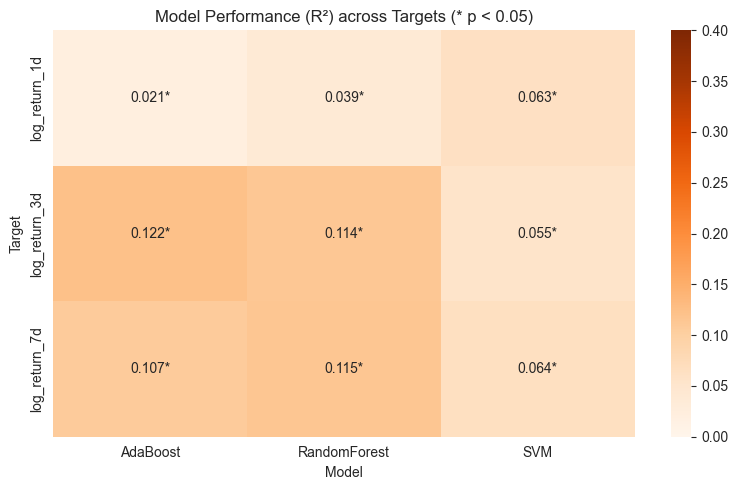

(Model          AdaBoost  RandomForest       SVM
 Target                                         
 log_return_1d  0.020525      0.039001  0.063374
 log_return_3d  0.122256      0.113745  0.055012
 log_return_7d  0.106776      0.114655  0.064471,
 Model          AdaBoost  RandomForest       SVM
 Target                                         
 log_return_1d  0.302652      0.330365  0.299650
 log_return_3d  0.378788      0.389758  0.338409
 log_return_7d  0.389717      0.396869  0.372866)

In [25]:
# AA data
df_btc = data
results = []
for target in targets:
    df_btc['target'] = add_target(df_btc, target_type=target)
    X_train, X_test, y_train, y_test, preprocessor = get_splits_process(
        df_btc, split_pct=0.8, include_return_price=True, price_return_only=True
    )
    results = run_all_model(X_train, X_test, y_train, y_test, preprocessor, results)
# results_price = run_all_model(X_train, X_test, y_train, y_test, preprocessor)

results_price_df = pd.DataFrame(results, columns=['Target', 'Model', 'R2', 'Corr', 'p-value'])
show_results(results_price_df)

Comparing the difference:

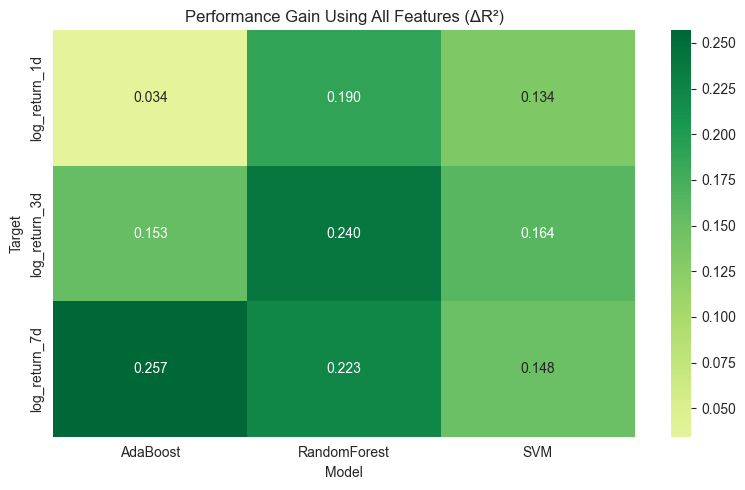

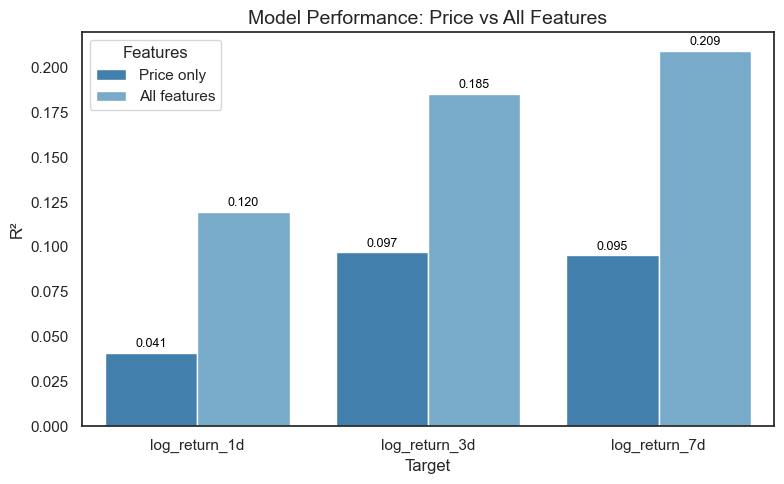

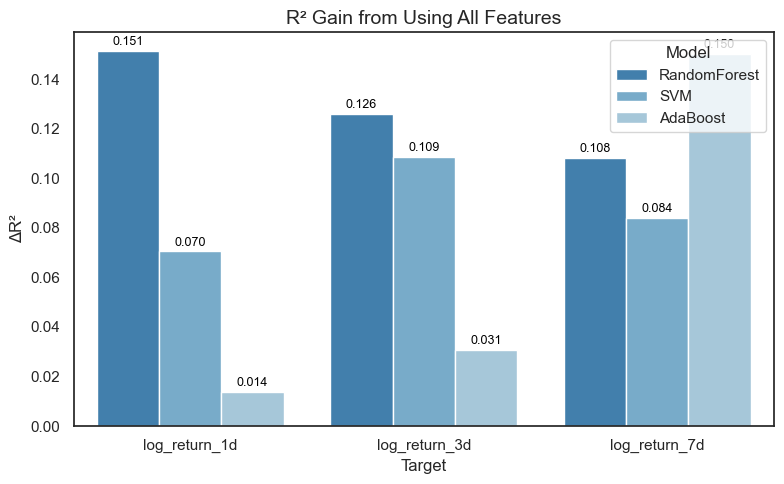

Paired t-test p-value: 0.00041754344148516216


In [26]:
plt.close('all')
plot_improvement(results_all_df, results_price_df)

## Other assets


### SOL

In [31]:
file = '../../data/audioalpha_5march.csv'
start_date = pd.to_datetime('2024-01-1')
end_date = pd.to_datetime('2026-03-4')
ticker = 'SOL'

data = load_df(file, start_date, end_date, ticker)

# Example for one target
targets = ['log_return_1d', 'log_return_3d', 'log_return_7d']
models = ['RandomForest', 'SVM', 'AdaBoost']



Model RandomForest R² on test set: 0.0813
Correlation: 0.35170679640518765 p-value: 5.859077874789951e-06

Model R² on SVM test set: 0.1111
Correlation: 0.47232878206704076 p-value: 3.715840840620703e-10

Model R² on ADAboost test set: 0.0890
Correlation: 0.3220729919208293 p-value: 3.679147192919271e-05

Model RandomForest R² on test set: 0.0953
Correlation: 0.37455693718638505 p-value: 1.2445998700734086e-06

Model R² on SVM test set: 0.0638
Correlation: 0.41182163067440425 p-value: 7.619858229127603e-08

Model R² on ADAboost test set: 0.0555
Correlation: 0.24929378799287805 p-value: 0.0015846569582038963

Model RandomForest R² on test set: 0.0710
Correlation: 0.4313274569874696 p-value: 1.532763642788631e-08

Model R² on SVM test set: 0.0697
Correlation: 0.4531264224800806 p-value: 2.2555232058481134e-09

Model R² on ADAboost test set: 0.0714
Correlation: 0.34447145411841645 p-value: 9.337619815387345e-06


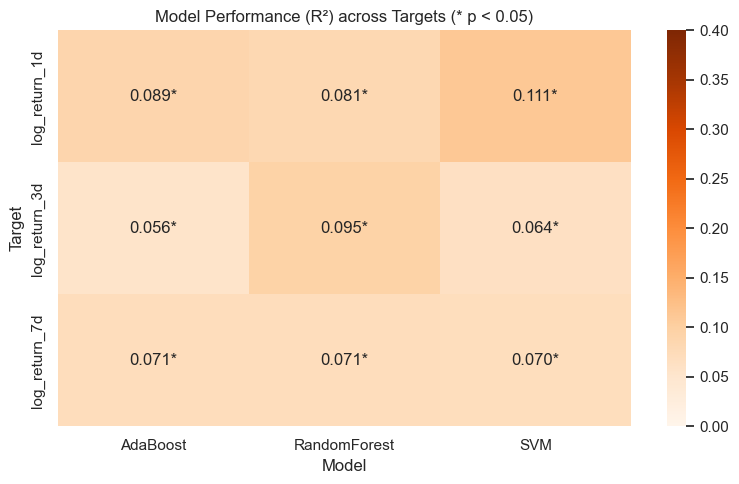

(Model          AdaBoost  RandomForest       SVM
 Target                                         
 log_return_1d  0.089011      0.081328  0.111092
 log_return_3d  0.055540      0.095283  0.063775
 log_return_7d  0.071440      0.070971  0.069697,
 Model          AdaBoost  RandomForest       SVM
 Target                                         
 log_return_1d  0.322073      0.351707  0.472329
 log_return_3d  0.249294      0.374557  0.411822
 log_return_7d  0.344471      0.431327  0.453126)

In [32]:
# AA data
df_btc = data
results = []
for target in targets:
    df_btc['target'] = add_target(df_btc, target_type=target)
    X_train, X_test, y_train, y_test, preprocessor = get_splits_process(
        df_btc, split_pct=0.8, include_return_price=False
    )
    results = run_all_model(X_train, X_test, y_train, y_test, preprocessor, results)
# results_price = run_all_model(X_train, X_test, y_train, y_test, preprocessor)

results_audioalpha_df = pd.DataFrame(results, columns=['Target', 'Model', 'R2', 'Corr', 'p-value'])
show_results(results_audioalpha_df)


Model RandomForest R² on test set: 0.3718
Correlation: 0.6140920773207282 p-value: 9.465761541220872e-18

Model R² on SVM test set: 0.0917
Correlation: 0.5947587364575726 p-value: 1.7271481952254284e-16

Model R² on ADAboost test set: 0.3636
Correlation: 0.6119935963251857 p-value: 1.3098769666289177e-17

Model RandomForest R² on test set: 0.2973
Correlation: 0.5551225459898056 p-value: 3.7559131240384754e-14

Model R² on SVM test set: 0.0675
Correlation: 0.567607116869586 p-value: 7.448333150334207e-15

Model R² on ADAboost test set: 0.3047
Correlation: 0.5637345390198159 p-value: 1.2392910299374553e-14

Model RandomForest R² on test set: 0.3639
Correlation: 0.6119117276187125 p-value: 1.326517812832176e-17

Model R² on SVM test set: 0.0658
Correlation: 0.5936784984142371 p-value: 2.0198445587958047e-16

Model R² on ADAboost test set: 0.3866
Correlation: 0.6396834759333494 p-value: 1.4705546803582324e-19


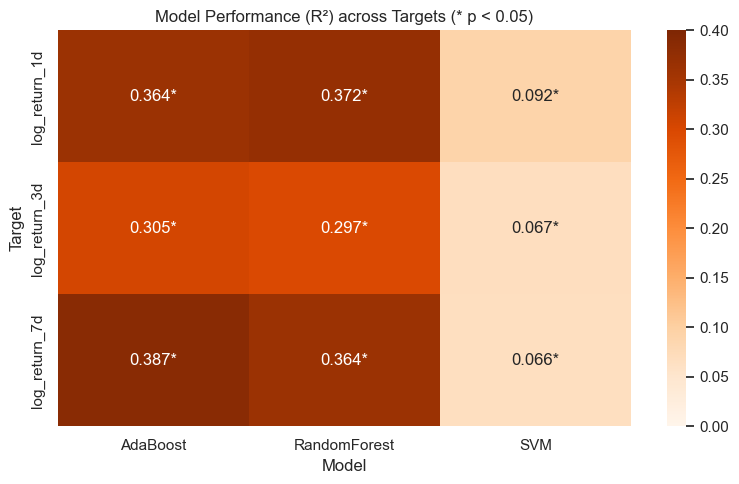

(Model          AdaBoost  RandomForest       SVM
 Target                                         
 log_return_1d  0.363598      0.371841  0.091687
 log_return_3d  0.304708      0.297281  0.067495
 log_return_7d  0.386603      0.363890  0.065755,
 Model          AdaBoost  RandomForest       SVM
 Target                                         
 log_return_1d  0.611994      0.614092  0.594759
 log_return_3d  0.563735      0.555123  0.567607
 log_return_7d  0.639683      0.611912  0.593678)

In [33]:
# AA data
df_btc = data
results = []
for target in targets:
    df_btc['target'] = add_target(df_btc, target_type=target)
    X_train, X_test, y_train, y_test, preprocessor = get_splits_process(
        df_btc, split_pct=0.8, include_return_price=True, price_return_only=True
    )
    results = run_all_model(X_train, X_test, y_train, y_test, preprocessor, results)
# results_price = run_all_model(X_train, X_test, y_train, y_test, preprocessor)

results_price_df = pd.DataFrame(results, columns=['Target', 'Model', 'R2', 'Corr', 'p-value'])
show_results(results_price_df)


Model RandomForest R² on test set: 0.3452
Correlation: 0.6517049100357274 p-value: 1.8097082090531836e-20

Model R² on SVM test set: 0.3537
Correlation: 0.6949489496815039 p-value: 4.1219922982071e-24

Model R² on ADAboost test set: 0.4943
Correlation: 0.7089105445735288 p-value: 1.9841888068275767e-25

Model RandomForest R² on test set: 0.3195
Correlation: 0.6672347653045215 p-value: 1.0460414875200378e-21

Model R² on SVM test set: 0.2493
Correlation: 0.6654824574712459 p-value: 1.455296581269088e-21

Model R² on ADAboost test set: 0.4007
Correlation: 0.6611729133993389 p-value: 3.2474847209594805e-21

Model RandomForest R² on test set: 0.3707
Correlation: 0.7226012443155103 p-value: 8.469645142302582e-27

Model R² on SVM test set: 0.2913
Correlation: 0.709001337769998 p-value: 1.944289413910844e-25

Model R² on ADAboost test set: 0.5015
Correlation: 0.7158042279982593 p-value: 4.149218809407301e-26


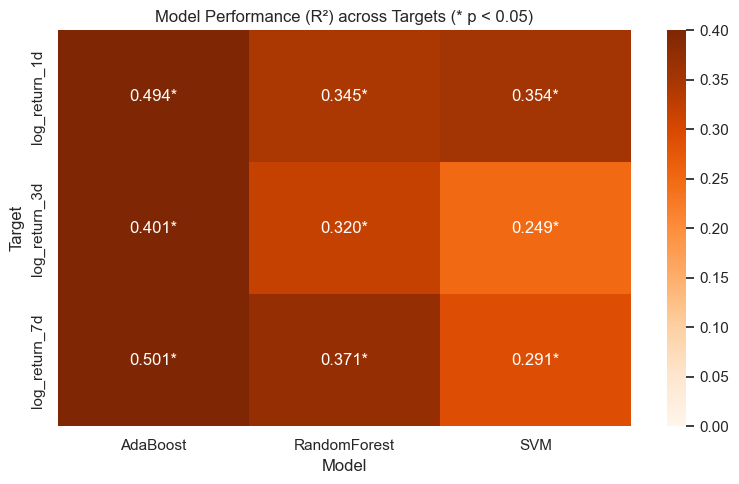

(Model          AdaBoost  RandomForest       SVM
 Target                                         
 log_return_1d  0.494278      0.345235  0.353711
 log_return_3d  0.400692      0.319530  0.249295
 log_return_7d  0.501482      0.370688  0.291323,
 Model          AdaBoost  RandomForest       SVM
 Target                                         
 log_return_1d  0.708911      0.651705  0.694949
 log_return_3d  0.661173      0.667235  0.665482
 log_return_7d  0.715804      0.722601  0.709001)

In [34]:
# AA data
df_btc = data
results = []
for target in targets:
    df_btc['target'] = add_target(df_btc, target_type=target)
    X_train, X_test, y_train, y_test, preprocessor = get_splits_process(
        df_btc, split_pct=0.8, include_return_price=True
    )
    results = run_all_model(X_train, X_test, y_train, y_test, preprocessor, results)
# results_price = run_all_model(X_train, X_test, y_train, y_test, preprocessor)

results_all_df = pd.DataFrame(results, columns=['Target', 'Model', 'R2', 'Corr', 'p-value'])
show_results(results_all_df)

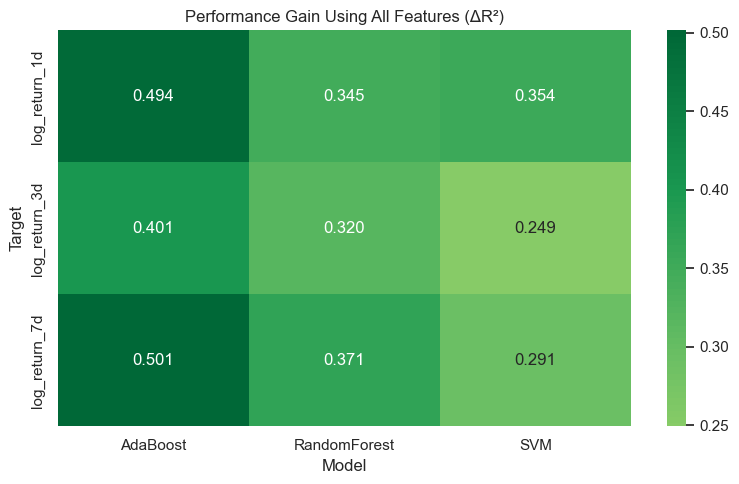

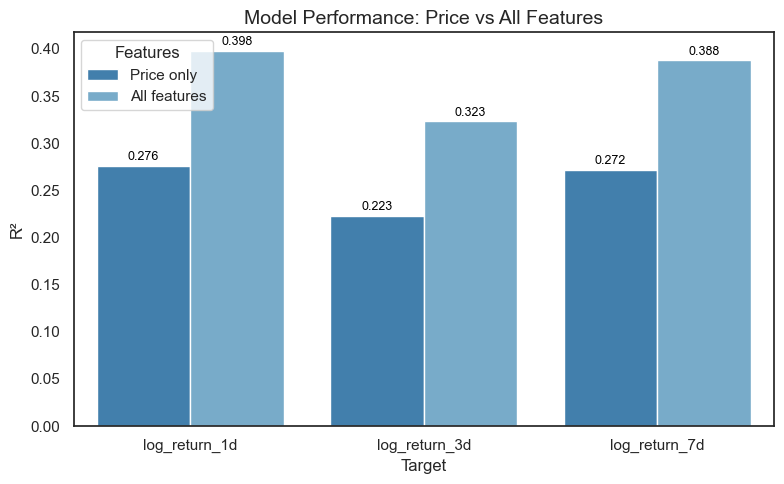

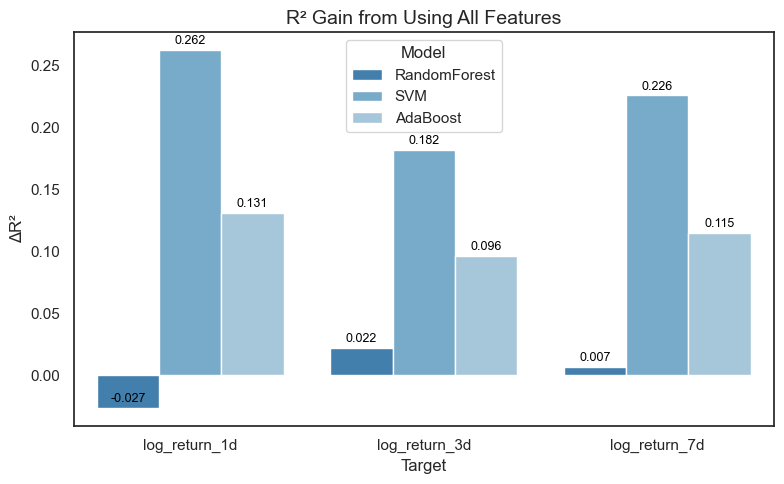

Paired t-test p-value: 0.009437479423657703


In [35]:
plt.close('all')
plot_improvement(results_all_df, results_price_df)

### ETH

In [36]:
file = '../../data/audioalpha_5march.csv'
start_date = pd.to_datetime('2024-01-1')
end_date = pd.to_datetime('2026-03-4')
ticker = 'ETH'

data = load_df(file, start_date, end_date, ticker)

# Example for one target
targets = ['log_return_1d', 'log_return_3d', 'log_return_7d']
models = ['RandomForest', 'SVM', 'AdaBoost']



Model RandomForest R² on test set: -0.0708
Correlation: 0.3177745577191954 p-value: 4.471164359531957e-05

Model R² on SVM test set: -0.0291
Correlation: 0.3991318279287651 p-value: 1.8743998110017321e-07

Model R² on ADAboost test set: -0.0253
Correlation: 0.30511697465922405 p-value: 9.20320401570473e-05

Model RandomForest R² on test set: -0.1663
Correlation: 0.3100251711441616 p-value: 6.98308060523715e-05

Model R² on SVM test set: -0.0741
Correlation: 0.3810307176429293 p-value: 7.236015903573089e-07

Model R² on ADAboost test set: -0.1456
Correlation: 0.2539758757203945 p-value: 0.001236249859444636

Model RandomForest R² on test set: 0.0241
Correlation: 0.44012597394544795 p-value: 6.434801378999133e-09

Model R² on SVM test set: 0.0222
Correlation: 0.4419269926037812 p-value: 5.4906969596962446e-09

Model R² on ADAboost test set: 0.0426
Correlation: 0.429988091633998 p-value: 1.5453031099133903e-08


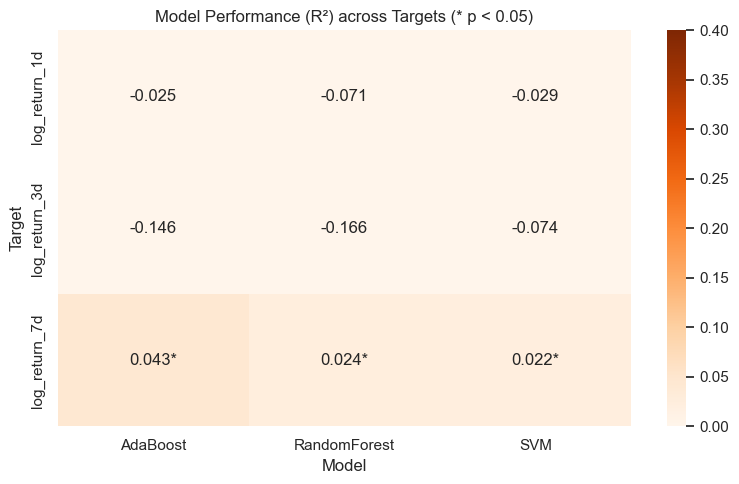

(Model          AdaBoost  RandomForest       SVM
 Target                                         
 log_return_1d -0.025271     -0.070833 -0.029150
 log_return_3d -0.145577     -0.166251 -0.074052
 log_return_7d  0.042615      0.024071  0.022233,
 Model          AdaBoost  RandomForest       SVM
 Target                                         
 log_return_1d  0.305117      0.317775  0.399132
 log_return_3d  0.253976      0.310025  0.381031
 log_return_7d  0.429988      0.440126  0.441927)

In [37]:
# AA data
df_btc = data
results = []
for target in targets:
    df_btc['target'] = add_target(df_btc, target_type=target)
    X_train, X_test, y_train, y_test, preprocessor = get_splits_process(
        df_btc, split_pct=0.8, include_return_price=False
    )
    results = run_all_model(X_train, X_test, y_train, y_test, preprocessor, results)
# results_price = run_all_model(X_train, X_test, y_train, y_test, preprocessor)

results_audioalpha_df = pd.DataFrame(results, columns=['Target', 'Model', 'R2', 'Corr', 'p-value'])
show_results(results_audioalpha_df)


Model RandomForest R² on test set: 0.2051
Correlation: 0.4984637894291428 p-value: 2.2893912142923466e-11

Model R² on SVM test set: 0.0847
Correlation: 0.4823471919299128 p-value: 1.2104539432589378e-10

Model R² on ADAboost test set: 0.2173
Correlation: 0.4972617104388368 p-value: 2.6000032647015618e-11

Model RandomForest R² on test set: -0.0112
Correlation: 0.32102369665140923 p-value: 3.6952203335969815e-05

Model R² on SVM test set: 0.0094
Correlation: 0.31517636602059834 p-value: 5.199178547846211e-05

Model R² on ADAboost test set: -0.0131
Correlation: 0.3191455643204816 p-value: 4.1267345147172564e-05

Model RandomForest R² on test set: 0.1504
Correlation: 0.42601900220350825 p-value: 2.1607529490787284e-08

Model R² on SVM test set: 0.0662
Correlation: 0.44553322216629926 p-value: 3.985113003770191e-09

Model R² on ADAboost test set: 0.1637
Correlation: 0.4378851050772407 p-value: 7.829129177321118e-09


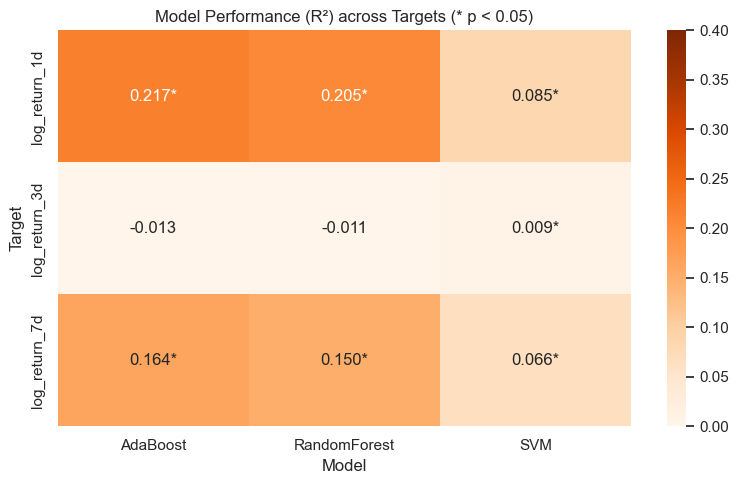

(Model          AdaBoost  RandomForest       SVM
 Target                                         
 log_return_1d  0.217257      0.205073  0.084659
 log_return_3d -0.013096     -0.011172  0.009385
 log_return_7d  0.163718      0.150405  0.066228,
 Model          AdaBoost  RandomForest       SVM
 Target                                         
 log_return_1d  0.497262      0.498464  0.482347
 log_return_3d  0.319146      0.321024  0.315176
 log_return_7d  0.437885      0.426019  0.445533)

In [38]:
# AA data
df_btc = data
results = []
for target in targets:
    df_btc['target'] = add_target(df_btc, target_type=target)
    X_train, X_test, y_train, y_test, preprocessor = get_splits_process(
        df_btc, split_pct=0.8, include_return_price=True, price_return_only=True
    )
    results = run_all_model(X_train, X_test, y_train, y_test, preprocessor, results)
# results_price = run_all_model(X_train, X_test, y_train, y_test, preprocessor)

results_price_df = pd.DataFrame(results, columns=['Target', 'Model', 'R2', 'Corr', 'p-value'])
show_results(results_price_df)


Model RandomForest R² on test set: 0.2744
Correlation: 0.601225459633796 p-value: 5.323346987040717e-17

Model R² on SVM test set: 0.1986
Correlation: 0.6077043882744546 p-value: 1.9994078896020176e-17

Model R² on ADAboost test set: 0.3808
Correlation: 0.6252539104532991 p-value: 1.2553474814539719e-18

Model RandomForest R² on test set: 0.1226
Correlation: 0.500729164574966 p-value: 1.7988905086898537e-11

Model R² on SVM test set: 0.0929
Correlation: 0.5018007500041426 p-value: 1.6039948677512442e-11

Model R² on ADAboost test set: 0.2568
Correlation: 0.5610265940934102 p-value: 1.4543378663121524e-14

Model RandomForest R² on test set: 0.2724
Correlation: 0.6029600695199349 p-value: 4.104570819552623e-17

Model R² on SVM test set: 0.1734
Correlation: 0.5937398996493962 p-value: 1.6058984299304548e-16

Model R² on ADAboost test set: 0.3386
Correlation: 0.596106002252221 p-value: 1.1362889028701707e-16


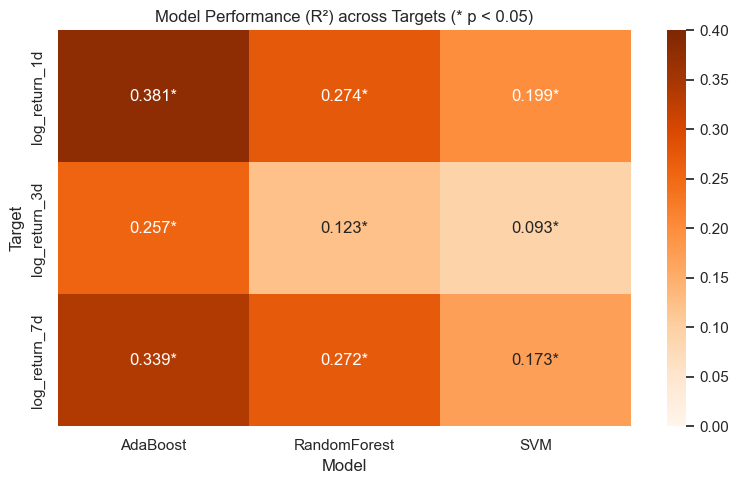

(Model          AdaBoost  RandomForest       SVM
 Target                                         
 log_return_1d  0.380783      0.274395  0.198610
 log_return_3d  0.256768      0.122563  0.092894
 log_return_7d  0.338573      0.272422  0.173429,
 Model          AdaBoost  RandomForest       SVM
 Target                                         
 log_return_1d  0.625254      0.601225  0.607704
 log_return_3d  0.561027      0.500729  0.501801
 log_return_7d  0.596106      0.602960  0.593740)

In [39]:
# AA data
df_btc = data
results = []
for target in targets:
    df_btc['target'] = add_target(df_btc, target_type=target)
    X_train, X_test, y_train, y_test, preprocessor = get_splits_process(
        df_btc, split_pct=0.8, include_return_price=True
    )
    results = run_all_model(X_train, X_test, y_train, y_test, preprocessor, results)
# results_price = run_all_model(X_train, X_test, y_train, y_test, preprocessor)

results_all_df = pd.DataFrame(results, columns=['Target', 'Model', 'R2', 'Corr', 'p-value'])
show_results(results_all_df)

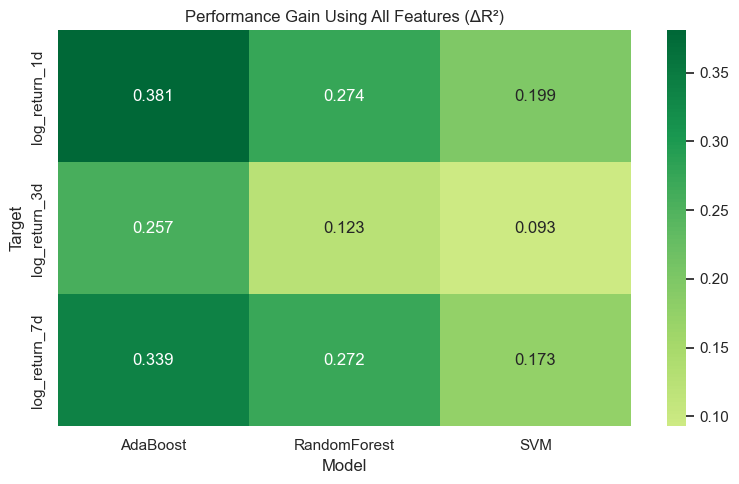

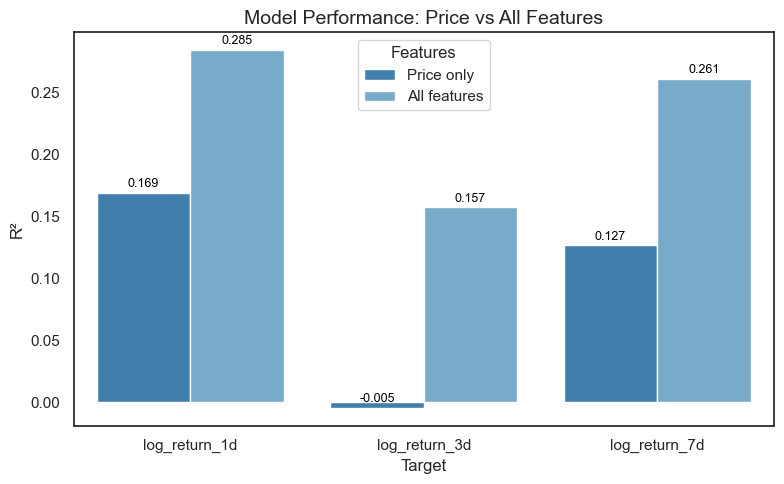

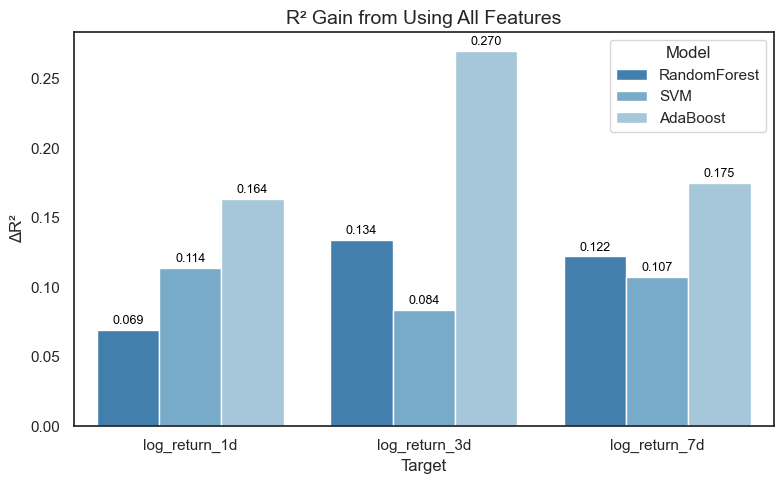

Paired t-test p-value: 0.0001286457880578353


In [40]:
plt.close('all')
plot_improvement(results_all_df, results_price_df)

### DOGE

In [29]:
file = '../../data/audioalpha_5march.csv'
start_date = pd.to_datetime('2024-01-1')
end_date = pd.to_datetime('2026-03-4')
ticker = 'DOGE'

data = load_df(file, start_date, end_date, ticker)

# Example for one target
targets = ['log_return_1d', 'log_return_3d', 'log_return_7d']
models = ['RandomForest', 'SVM', 'AdaBoost']



Model RandomForest R² on test set: 0.2067
Correlation: 0.47192032054259103 p-value: 5.126572862834881e-09

Model R² on SVM test set: 0.2075
Correlation: 0.5990246864512083 p-value: 8.426043567820449e-15

Model R² on ADAboost test set: 0.0680
Correlation: 0.36063304301610866 p-value: 1.3922644291607536e-05

Model RandomForest R² on test set: 0.1771
Correlation: 0.45675383583974555 p-value: 1.7926762627515127e-08

Model R² on SVM test set: 0.1023
Correlation: 0.5026799434778713 p-value: 3.329561974122489e-10

Model R² on ADAboost test set: 0.0749
Correlation: 0.3389946291422211 p-value: 4.758944572295911e-05

Model RandomForest R² on test set: 0.1602
Correlation: 0.4575890311346995 p-value: 1.6758916404610352e-08

Model R² on SVM test set: 0.1192
Correlation: 0.48131895801398816 p-value: 2.2876322495824568e-09

Model R² on ADAboost test set: 0.1560
Correlation: 0.4692326603319333 p-value: 6.428521027761089e-09


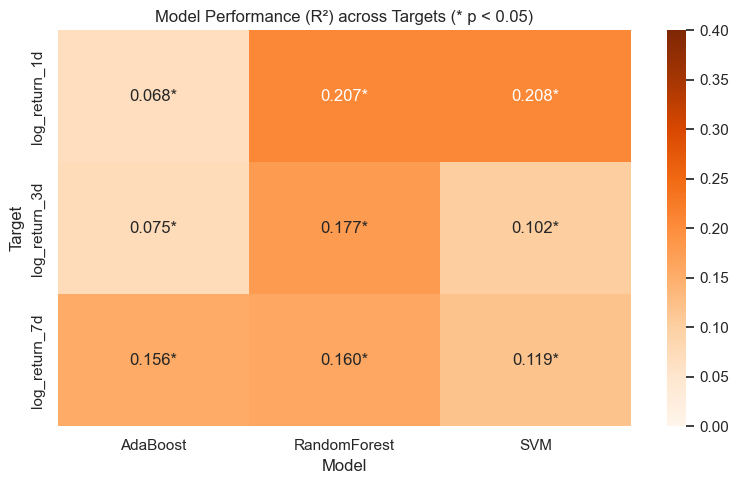

(Model          AdaBoost  RandomForest       SVM
 Target                                         
 log_return_1d  0.067966      0.206654  0.207548
 log_return_3d  0.074930      0.177065  0.102332
 log_return_7d  0.156019      0.160173  0.119248,
 Model          AdaBoost  RandomForest       SVM
 Target                                         
 log_return_1d  0.360633      0.471920  0.599025
 log_return_3d  0.338995      0.456754  0.502680
 log_return_7d  0.469233      0.457589  0.481319)

In [30]:
# AA data
df_btc = data
results = []
for target in targets:
    df_btc['target'] = add_target(df_btc, target_type=target)
    X_train, X_test, y_train, y_test, preprocessor = get_splits_process(
        df_btc, split_pct=0.8, include_return_price=False
    )
    results = run_all_model(X_train, X_test, y_train, y_test, preprocessor, results)
# results_price = run_all_model(X_train, X_test, y_train, y_test, preprocessor)

results_audioalpha_df = pd.DataFrame(results, columns=['Target', 'Model', 'R2', 'Corr', 'p-value'])
show_results(results_audioalpha_df)


Model RandomForest R² on test set: 0.2514
Correlation: 0.5192597707043369 p-value: 6.787818608262391e-11

Model R² on SVM test set: 0.0282
Correlation: 0.5702708157793326 p-value: 2.854344526291535e-13

Model R² on ADAboost test set: 0.2839
Correlation: 0.550416636657066 p-value: 2.681042488242017e-12

Model RandomForest R² on test set: 0.2327
Correlation: 0.49175380603322616 p-value: 9.072022891475712e-10

Model R² on SVM test set: 0.0221
Correlation: 0.4986135655298099 p-value: 4.855055256650112e-10

Model R² on ADAboost test set: 0.2262
Correlation: 0.485906407601913 p-value: 1.5291680786193025e-09

Model RandomForest R² on test set: 0.3142
Correlation: 0.574286284502314 p-value: 1.7813831655015873e-13

Model R² on SVM test set: 0.0331
Correlation: 0.5720030052739042 p-value: 2.3308929063981343e-13

Model R² on ADAboost test set: 0.3337
Correlation: 0.5828503930536941 p-value: 6.377539407038977e-14


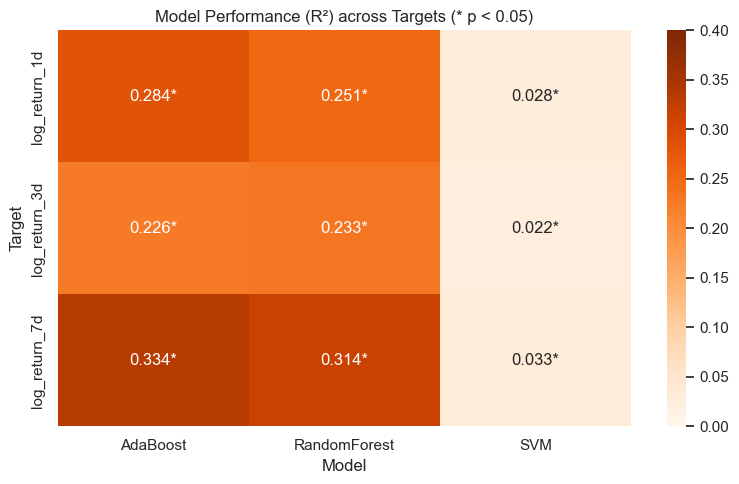

(Model          AdaBoost  RandomForest       SVM
 Target                                         
 log_return_1d  0.283897      0.251392  0.028176
 log_return_3d  0.226187      0.232691  0.022075
 log_return_7d  0.333732      0.314240  0.033071,
 Model          AdaBoost  RandomForest       SVM
 Target                                         
 log_return_1d  0.550417      0.519260  0.570271
 log_return_3d  0.485906      0.491754  0.498614
 log_return_7d  0.582850      0.574286  0.572003)

In [31]:
# AA data
df_btc = data
results = []
for target in targets:
    df_btc['target'] = add_target(df_btc, target_type=target)
    X_train, X_test, y_train, y_test, preprocessor = get_splits_process(
        df_btc, split_pct=0.8, include_return_price=True, price_return_only=True
    )
    results = run_all_model(X_train, X_test, y_train, y_test, preprocessor, results)
# results_price = run_all_model(X_train, X_test, y_train, y_test, preprocessor)

results_price_df = pd.DataFrame(results, columns=['Target', 'Model', 'R2', 'Corr', 'p-value'])
show_results(results_price_df)


Model RandomForest R² on test set: 0.4028
Correlation: 0.6740893917419564 p-value: 1.2870613774715402e-19

Model R² on SVM test set: 0.3276
Correlation: 0.6864317759191194 p-value: 1.5092699148734132e-20

Model R² on ADAboost test set: 0.5063
Correlation: 0.7142485312866759 p-value: 7.975990386677667e-23

Model RandomForest R² on test set: 0.3605
Correlation: 0.6396604967794887 p-value: 3.0455434134627853e-17

Model R² on SVM test set: 0.2083
Correlation: 0.6030823328533296 p-value: 4.9805521847460835e-15

Model R² on ADAboost test set: 0.4364
Correlation: 0.6855918566208176 p-value: 1.7521417582643854e-20

Model RandomForest R² on test set: 0.3722
Correlation: 0.6644263031962061 p-value: 6.420940117090126e-19

Model R² on SVM test set: 0.2075
Correlation: 0.585383541519725 p-value: 4.6793840371348633e-14

Model R² on ADAboost test set: 0.3910
Correlation: 0.6727597168267713 p-value: 1.6114124294564852e-19


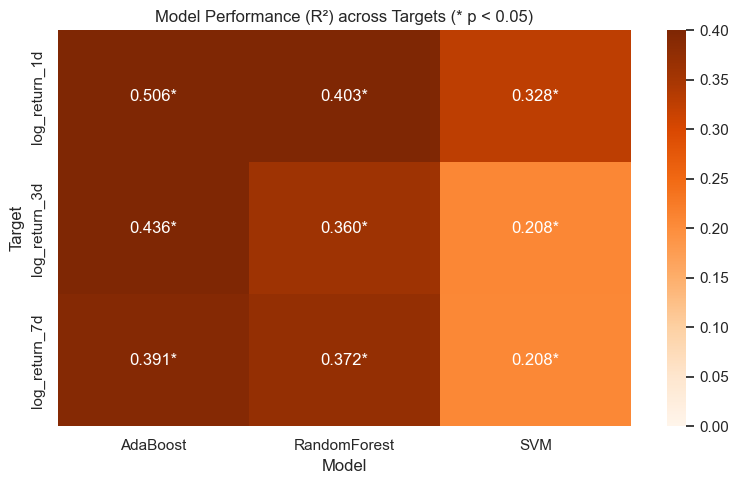

(Model          AdaBoost  RandomForest       SVM
 Target                                         
 log_return_1d  0.506310      0.402761  0.327588
 log_return_3d  0.436360      0.360472  0.208277
 log_return_7d  0.390966      0.372183  0.207517,
 Model          AdaBoost  RandomForest       SVM
 Target                                         
 log_return_1d  0.714249      0.674089  0.686432
 log_return_3d  0.685592      0.639660  0.603082
 log_return_7d  0.672760      0.664426  0.585384)

In [32]:
# AA data
df_btc = data
results = []
for target in targets:
    df_btc['target'] = add_target(df_btc, target_type=target)
    X_train, X_test, y_train, y_test, preprocessor = get_splits_process(
        df_btc, split_pct=0.8, include_return_price=True
    )
    results = run_all_model(X_train, X_test, y_train, y_test, preprocessor, results)
# results_price = run_all_model(X_train, X_test, y_train, y_test, preprocessor)

results_all_df = pd.DataFrame(results, columns=['Target', 'Model', 'R2', 'Corr', 'p-value'])
show_results(results_all_df)

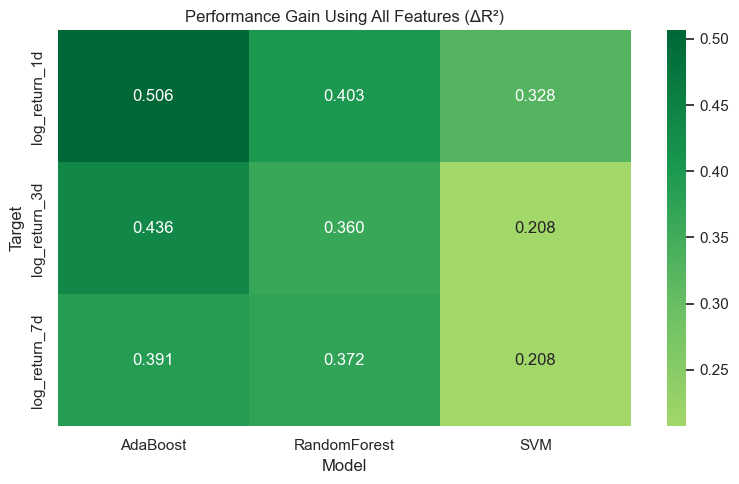

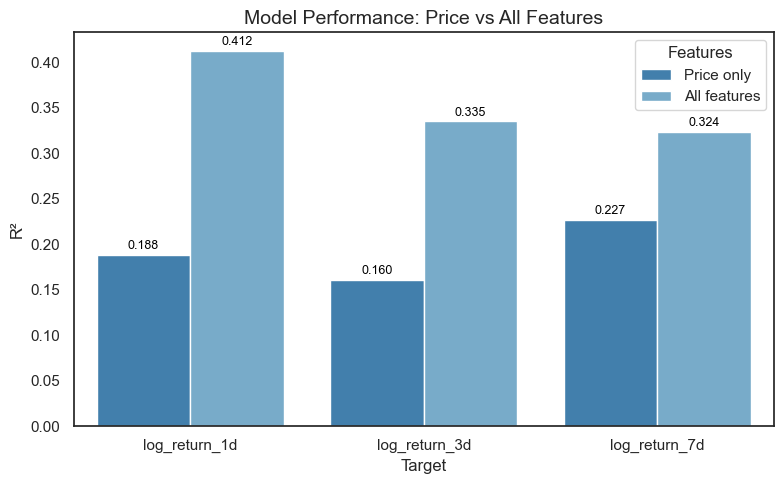

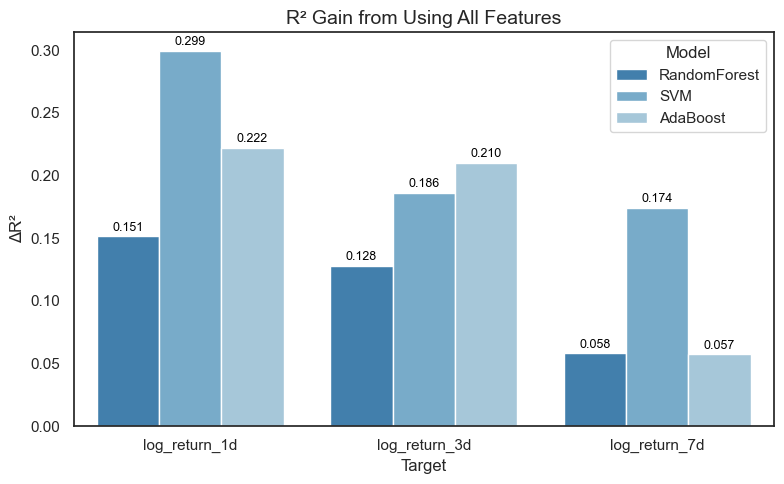

Paired t-test p-value: 0.00021823364241248513


In [33]:
plt.close('all')
plot_improvement(results_all_df, results_price_df)

### AVAX

In [17]:
file = '../../data/audioalpha_5march.csv'
start_date = pd.to_datetime('2024-01-1')
end_date = pd.to_datetime('2026-03-4')
ticker = 'AVAX'

data = load_df(file, start_date, end_date, ticker)

# Example for one target
targets = ['log_return_1d', 'log_return_3d', 'log_return_7d']
models = ['RandomForest', 'SVM', 'AdaBoost']



Model RandomForest R² on test set: 0.0826
Correlation: 0.662815412742633 p-value: 1.6337133634324056e-16

Model R² on SVM test set: 0.0597
Correlation: 0.687030489129254 p-value: 4.5605375301560715e-18

Model R² on ADAboost test set: 0.1380
Correlation: 0.65030429159213 p-value: 9.144496371845124e-16

Model RandomForest R² on test set: 0.1756
Correlation: 0.6815461838551862 p-value: 1.0569772374037756e-17

Model R² on SVM test set: 0.0959
Correlation: 0.6946825390455821 p-value: 1.3678976501708854e-18

Model R² on ADAboost test set: 0.1918
Correlation: 0.6266980181846393 p-value: 1.9109900149321946e-14

Model RandomForest R² on test set: 0.1170
Correlation: 0.6354820032403512 p-value: 6.357776861445348e-15

Model R² on SVM test set: 0.0413
Correlation: 0.6666265302751094 p-value: 9.509811375327793e-17

Model R² on ADAboost test set: 0.1632
Correlation: 0.5139851503070134 p-value: 1.923378059258783e-09


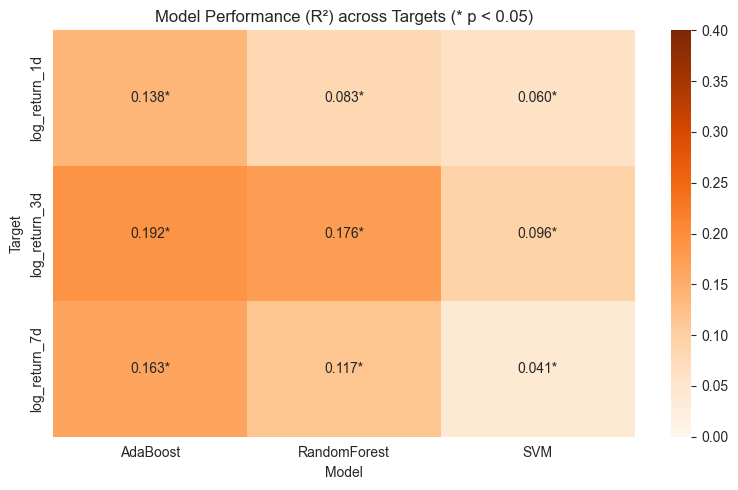

(Model          AdaBoost  RandomForest       SVM
 Target                                         
 log_return_1d  0.137953      0.082603  0.059663
 log_return_3d  0.191773      0.175573  0.095856
 log_return_7d  0.163201      0.117041  0.041252,
 Model          AdaBoost  RandomForest       SVM
 Target                                         
 log_return_1d  0.650304      0.662815  0.687030
 log_return_3d  0.626698      0.681546  0.694683
 log_return_7d  0.513985      0.635482  0.666627)

In [18]:
# AA data
df_btc = data
results = []
for target in targets:
    df_btc['target'] = add_target(df_btc, target_type=target)
    X_train, X_test, y_train, y_test, preprocessor = get_splits_process(
        df_btc, split_pct=0.8, include_return_price=True
    )
    results = run_all_model(X_train, X_test, y_train, y_test, preprocessor, results)
# results_price = run_all_model(X_train, X_test, y_train, y_test, preprocessor)

results_all_df = pd.DataFrame(results, columns=['Target', 'Model', 'R2', 'Corr', 'p-value'])
show_results(results_all_df)


Model RandomForest R² on test set: 0.1432
Correlation: 0.5474427284048324 p-value: 9.787089505065611e-11

Model R² on SVM test set: -0.1742
Correlation: 0.621026251890137 p-value: 3.818846553887959e-14

Model R² on ADAboost test set: 0.2003
Correlation: 0.6192706501052421 p-value: 4.7181585193447285e-14

Model RandomForest R² on test set: 0.2382
Correlation: 0.5597374024299744 p-value: 3.0097006969610285e-11

Model R² on SVM test set: -0.0649
Correlation: 0.5915216474817176 p-value: 1.1285903857281979e-12

Model R² on ADAboost test set: 0.2496
Correlation: 0.5821679328570475 p-value: 3.0777926574824184e-12

Model RandomForest R² on test set: 0.2264
Correlation: 0.5615961244369725 p-value: 2.5076316340032787e-11

Model R² on SVM test set: -0.1225
Correlation: 0.6060016317153774 p-value: 2.2374790677813837e-13

Model R² on ADAboost test set: 0.2430
Correlation: 0.5776472432867767 p-value: 4.941875778759505e-12


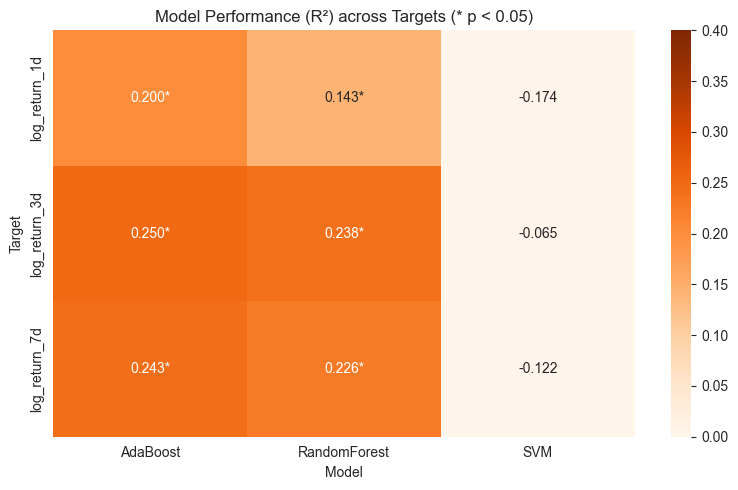

(Model          AdaBoost  RandomForest       SVM
 Target                                         
 log_return_1d  0.200300      0.143212 -0.174208
 log_return_3d  0.249636      0.238223 -0.064896
 log_return_7d  0.243044      0.226355 -0.122500,
 Model          AdaBoost  RandomForest       SVM
 Target                                         
 log_return_1d  0.619271      0.547443  0.621026
 log_return_3d  0.582168      0.559737  0.591522
 log_return_7d  0.577647      0.561596  0.606002)

In [19]:
# AA data
df_btc = data
results = []
for target in targets:
    df_btc['target'] = add_target(df_btc, target_type=target)
    X_train, X_test, y_train, y_test, preprocessor = get_splits_process(
        df_btc, split_pct=0.8, include_return_price=True, price_return_only=True
    )
    results = run_all_model(X_train, X_test, y_train, y_test, preprocessor, results)
# results_price = run_all_model(X_train, X_test, y_train, y_test, preprocessor)

results_price_df = pd.DataFrame(results, columns=['Target', 'Model', 'R2', 'Corr', 'p-value'])
show_results(results_price_df)


Model RandomForest R² on test set: -0.1159
Correlation: 0.4882287061848243 p-value: 1.543673095982199e-08

Model R² on SVM test set: -0.0556
Correlation: 0.559492566023318 p-value: 3.082670368334207e-11

Model R² on ADAboost test set: -0.0566
Correlation: 0.5132153205185672 p-value: 2.0521100467119284e-09

Model RandomForest R² on test set: 0.0195
Correlation: 0.5435312488815076 p-value: 1.4101669646792116e-10

Model R² on SVM test set: -0.0114
Correlation: 0.5857281177943481 p-value: 2.108833529079396e-12

Model R² on ADAboost test set: 0.0430
Correlation: 0.5177016595913368 p-value: 1.4035985161646307e-09

Model RandomForest R² on test set: -0.0656
Correlation: 0.5302239621035711 p-value: 4.719669278276839e-10

Model R² on SVM test set: -0.0739
Correlation: 0.5420248866374064 p-value: 1.621114622122399e-10

Model R² on ADAboost test set: -0.0826
Correlation: 0.4684517316193022 p-value: 6.825059196212437e-08


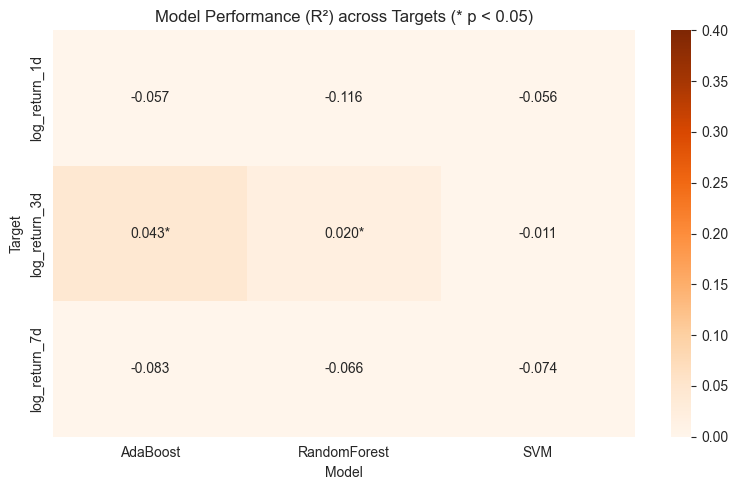

(Model          AdaBoost  RandomForest       SVM
 Target                                         
 log_return_1d -0.056598     -0.115949 -0.055635
 log_return_3d  0.042963      0.019532 -0.011350
 log_return_7d -0.082629     -0.065581 -0.073895,
 Model          AdaBoost  RandomForest       SVM
 Target                                         
 log_return_1d  0.513215      0.488229  0.559493
 log_return_3d  0.517702      0.543531  0.585728
 log_return_7d  0.468452      0.530224  0.542025)

In [20]:
# AA data
df_btc = data
results = []
for target in targets:
    df_btc['target'] = add_target(df_btc, target_type=target)
    X_train, X_test, y_train, y_test, preprocessor = get_splits_process(
        df_btc, split_pct=0.8, include_return_price=False,
    )
    results = run_all_model(X_train, X_test, y_train, y_test, preprocessor, results)
# results_price = run_all_model(X_train, X_test, y_train, y_test, preprocessor)

results_audioalpha_df = pd.DataFrame(results, columns=['Target', 'Model', 'R2', 'Corr', 'p-value'])
show_results(results_audioalpha_df)

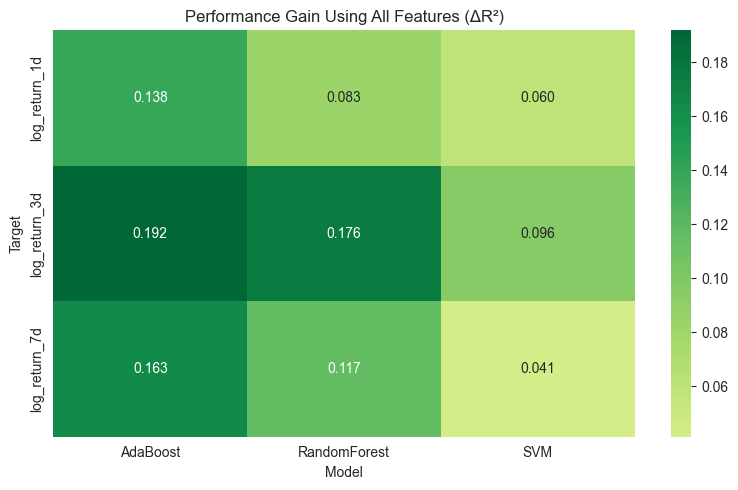

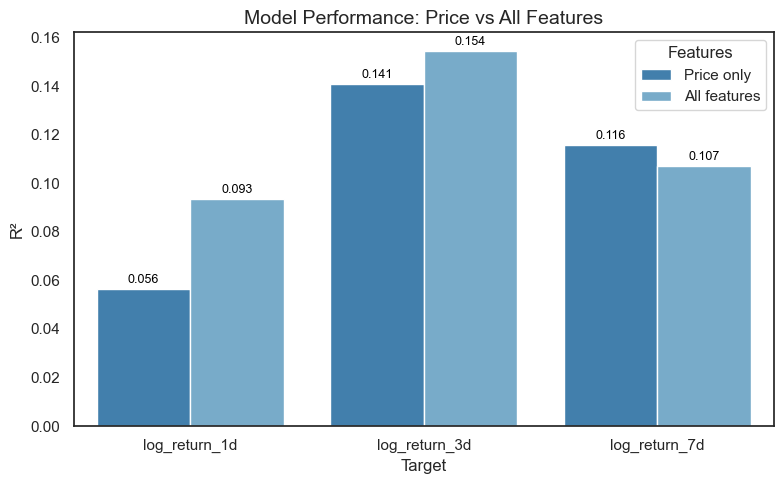

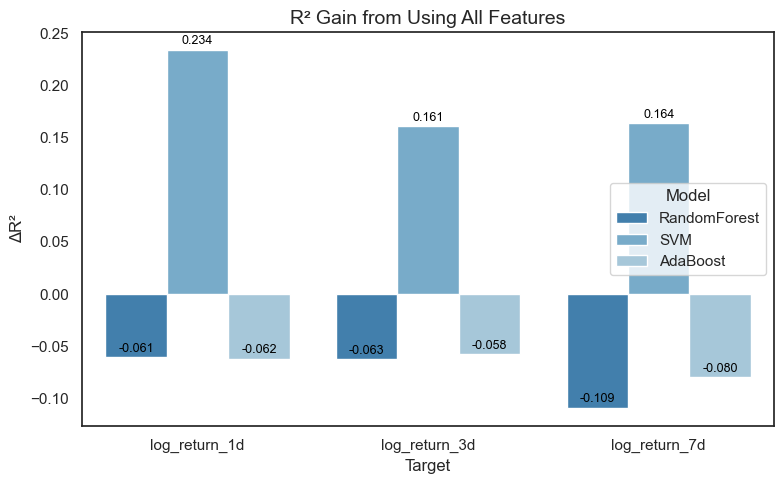

Paired t-test p-value: 0.7584218738315924


In [21]:
plt.close('all')
plot_improvement(results_all_df, results_price_df)

## Rolling window back

In [22]:
file = '../../data/audioalpha_5march.csv'
start_date = pd.to_datetime('2024-01-1')
end_date = pd.to_datetime('2025-10-30') # roughly end of previous split
ticker = 'ETH'

df_btc = load_df(file, start_date, end_date, ticker)

df_btc['target'] = add_target(df_btc, target_type='log_return_7d')
X_train, X_test, y_train, y_test, preprocessor = get_splits_process(df_btc, split_pct=0.7, include_return_price = False)
# print(X_train.columns)

In [24]:
r2_rf, corr_rf, pval_rf = run_randomForest(X_train, X_test, y_train, y_test, preprocessor=preprocessor, n_estimators=2000, min_samples_leaf=7, min_samples_split=10, max_features="sqrt", bootstrap=True, max_samples=0.8, max_depth = 5)
r2_svm, corr_svm, pval_svm = run_svm(X_train, X_test, y_train, y_test, preprocessor=preprocessor, C = 1., epsilon=0.02, kernel="rbf", gamma=0.1, grid_search= False, tol=1e-4, shrinking=True, max_iter=10000, degree=3)
r2_ada, corr_ada, pval_ada = run_adaBoost(X_train, X_test, y_train, y_test, preprocessor=preprocessor, n_estimators=20, learning_rate=0.05,max_depth=3 , min_samples_leaf=10, loss='exponential')


Model RandomForest R² on test set: 0.0461
Correlation: 0.28601600016590245 p-value: 3.85501373284442e-05

Model R² on SVM test set: 0.0171
Correlation: 0.2157741172392958 p-value: 0.0020953856858533107

Model R² on ADAboost test set: 0.0729
Correlation: 0.3622806993558881 p-value: 1.2583481339614698e-07
